# ISyE 6525 HW1 - Question 3

Goal: estimate the sample mean discharge curve with four smoothers, using the **same 5-fold split of the 200 time points** for every reported CV MSE.

Methods:

1. Cubic truncated-power spline; choose 5--30 interior knots by CV.
2. Cubic B-spline; choose 5--30 interior knots by CV.
3. Smoothing spline; choose $\lambda$ by GCV and report $\operatorname{tr}(S_\lambda)$.
4. Gaussian kernel regression; choose bandwidth by CV.


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from patsy import build_design_matrices, dmatrix

RANDOM_STATE = 25
N_SPLITS = 5
DATA_PATH = Path('Question3.csv')



In [25]:
##### Configure logging #####
import logging
import warnings

LOG_LEVEL = logging.WARNING

logging.basicConfig(
    level=LOG_LEVEL,
    format="%(levelname)s | %(name)s | %(message)s",
    force=True,  # reconfigure logging even if Jupyter initialized it already
)

# Reduce noise from specific libraries
for logger_name in ["matplotlib", "PIL", "sklearn"]:
    logging.getLogger(logger_name).setLevel(logging.WARNING)

# Keep warnings visible by default
warnings.filterwarnings("default")

def set_log_level(level):
    logging.getLogger().setLevel(level)

set_log_level(logging.INFO)     # change to DEBUG for more detailed output

logger = logging.getLogger(__name__)


## Load the data and compute the sample mean
For each time point \(t_j\), the sample mean is computed as follows:
$$
\bar y(t_j)=\frac{1}{50}\sum_{i=1}^{50}y_i(t_j).
$$

INFO | __main__ | y_bar shape = (200,)


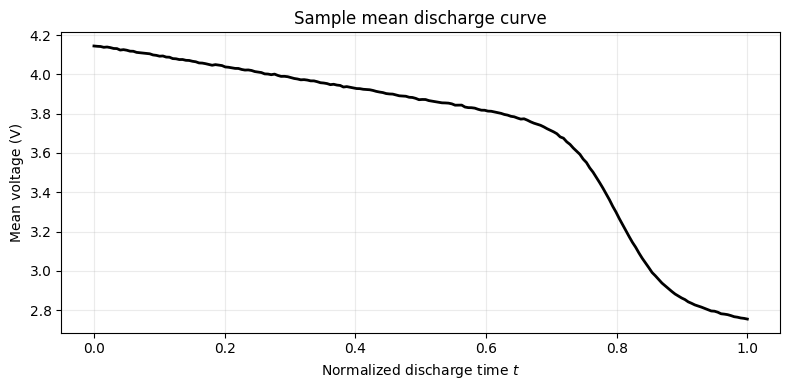

In [22]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Put {DATA_PATH.name} beside this notebook.')

profiles = pd.read_csv(DATA_PATH, header=None).to_numpy(dtype=float)
assert profiles.shape == (50, 200), f'Expected (50, 200), got {profiles.shape}'

t = np.linspace(0.0, 1.0, profiles.shape[1])
y_bar = profiles.mean(axis=0)
logger.info(f"y_bar shape = {y_bar.shape}")

plt.figure(figsize=(8, 4))
plt.plot(t, y_bar, color='black', linewidth=2)
plt.xlabel('Normalized discharge time $t$')
plt.ylabel('Mean voltage (V)')
plt.title('Sample mean discharge curve')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Common 5-fold CV setup

The split is materialized once and reused. `fit_predict` must fit only on `(t_train, y_train)` and return predictions at `t_valid`.

Keep this same `splits` object for all four methods. Do not recreate `KFold` inside a model loop.

In [23]:
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
splits = list(kf.split(t))

def cv_mse(fit_predict, x, y, splits, **params):
    out_of_fold = np.empty_like(y, dtype=float)
    
    logger.debug(f"x shape = {x.shape}, y shape = {y.shape}")
    logger.debug(f"Number of splits = {len(splits)}")
    for train_idx, valid_idx in splits:
        out_of_fold[valid_idx] = fit_predict(
            x[train_idx], y[train_idx], x[valid_idx], **params
        )

    return mean_squared_error(y, out_of_fold)

# Sanity check: every point should appear in exactly one validation fold.
valid_indices = np.concatenate([valid for _, valid in splits])
assert np.array_equal(np.sort(valid_indices), np.arange(len(t)))

## (a) Cubic spline with truncated-power basis

For interior knots $\xi_1,\ldots,\xi_K$, use

$$
1,t,t^2,t^3,(t-\xi_1)_+^3,\ldots,(t-\xi_K)_+^3.
$$


In [24]:
def truncated_power_design(x, knots):
    x = np.asarray(x, dtype=float)
    polynomial = np.column_stack([np.ones_like(x), x, x**2, x**3])
    logger.debug(f"Polynomial shape = {polynomial.shape}")
    logger.debug(f"x shape = {x.shape}")
    logger.debug(f"knots shape = {knots.shape}")
    truncated = np.maximum(x[:, None] - knots[None, :], 0.0) ** 3
    logger.debug(f"Truncated shape = {truncated.shape}")
    return np.column_stack([polynomial, truncated])

def truncated_power_fit_predict(x_train, y_train, x_valid, n_interior_knots):
    knots = np.linspace(0.0, 1.0, n_interior_knots + 2)[1:-1]
    model = LinearRegression(fit_intercept=False)
    basis = truncated_power_design(x_train, knots)
    logger.debug(f"Power truncated basis shape = {basis.shape}")
    model.fit(basis, y_train)
    return model.predict(truncated_power_design(x_valid, knots))

truncated_cv = {}
for K in range(5, 31):
    truncated_cv[K] = cv_mse(truncated_power_fit_predict, t, y_bar, splits, n_interior_knots=K)

best_truncated_k = min(truncated_cv, key=truncated_cv.get)
best_truncated_mse = truncated_cv[best_truncated_k]

logger.info(f"Best truncated power spline: K = {best_truncated_k}, CV MSE = {best_truncated_mse}")

DEBUG | __main__ | x shape = (200,), y shape = (200,)
DEBUG | __main__ | Number of splits = 5
DEBUG | __main__ | Polynomial shape = (160, 4)
DEBUG | __main__ | x shape = (160,)
DEBUG | __main__ | knots shape = (5,)
DEBUG | __main__ | Truncated shape = (160, 5)
DEBUG | __main__ | Power truncated basis shape = (160, 9)
DEBUG | __main__ | Polynomial shape = (40, 4)
DEBUG | __main__ | x shape = (40,)
DEBUG | __main__ | knots shape = (5,)
DEBUG | __main__ | Truncated shape = (40, 5)
DEBUG | __main__ | Polynomial shape = (160, 4)
DEBUG | __main__ | x shape = (160,)
DEBUG | __main__ | knots shape = (5,)
DEBUG | __main__ | Truncated shape = (160, 5)
DEBUG | __main__ | Power truncated basis shape = (160, 9)
DEBUG | __main__ | Polynomial shape = (40, 4)
DEBUG | __main__ | x shape = (40,)
DEBUG | __main__ | knots shape = (5,)
DEBUG | __main__ | Truncated shape = (40, 5)
DEBUG | __main__ | Polynomial shape = (160, 4)
DEBUG | __main__ | x shape = (160,)
DEBUG | __main__ | knots shape = (5,)
DEBUG |

## (b) Cubic B-spline

> TODO: use exactly 5--30 **interior** knots. The array passed below also contains the two boundary knots 0 and 1.

In [ ]:
def bspline_fit_predict(x_train, y_train, x_valid, n_interior_knots):
    interior_knots = np.linspace(0.0, 1.0, n_interior_knots + 2)[1:-1]
    formula = (
        f'bs(x, knots={interior_knots.tolist()}, degree=3, '
        'include_intercept=True, lower_bound=0, upper_bound=1) - 1'
    )
    train_basis = dmatrix(formula, {'x': x_train}, return_type='dataframe')
    X_train = np.asarray(train_basis)
    X_valid = np.asarray(
        build_design_matrices([train_basis.design_info], {'x': x_valid})[0]
    )
    model = LinearRegression(fit_intercept=False).fit(X_train, y_train)
    return model.predict(X_valid)

bspline_cv = {}
# TODO: fill bspline_cv[K] with cv_mse(...) for K in range(5, 31).
# best_bspline_k = min(bspline_cv, key=bspline_cv.get)
# best_bspline_mse = bspline_cv[best_bspline_k]

## (c) Smoothing spline

Choose $\lambda$ by minimizing

$$
\operatorname{GCV}(\lambda)=
\frac{\lVert(I-S_\lambda)y\rVert^2/n}
{(1-\operatorname{tr}(S_\lambda)/n)^2}.
$$

> TODO: implement or select a smoothing-spline routine that exposes the smoother matrix/effective degrees of freedom. Fit $\lambda$ using GCV on each training fold when computing honest CV MSE, then fit once on all 200 points for the final curve and reported $\lambda$ and $\operatorname{tr}(S_\lambda)$.

In [ ]:
def smoothing_spline_fit_predict(x_train, y_train, x_valid):
    # TODO: choose lambda by GCV using training data only.
    # Return predictions at x_valid. Also keep a separate full-data fit for
    # the final lambda, effective df, and plotted curve.
    raise NotImplementedError('Implement smoothing spline + GCV here')

# smoothing_cv_mse = cv_mse(smoothing_spline_fit_predict, t, y_bar, splits)

## (d) Gaussian kernel regression

Use the Nadaraya--Watson estimator

$$
\hat f(t)=\frac{\sum_i \exp[-(t-t_i)^2/(2h^2)]y_i}
{\sum_i \exp[-(t-t_i)^2/(2h^2)]}.
$$

> TODO: choose a reasonable positive bandwidth grid, plot CV MSE against $h$, and refine the grid near its minimum if needed.

In [ ]:
def kernel_fit_predict(x_train, y_train, x_valid, bandwidth):
    distances = (x_valid[:, None] - x_train[None, :]) / bandwidth
    weights = np.exp(-0.5 * distances**2)
    return (weights @ y_train) / weights.sum(axis=1)

bandwidth_grid = np.logspace(-2.5, -0.3, 40)
kernel_cv = {}
# TODO: fill kernel_cv[h] with cv_mse(...) for h in bandwidth_grid.
# best_bandwidth = min(kernel_cv, key=kernel_cv.get)
# best_kernel_mse = kernel_cv[best_bandwidth]

## (e) Results table and final plot

> TODO: refit every selected model on all 200 points, predict on a dense grid, complete the table, and plot the four fits with $\bar y(t)$. End with one or two sentences selecting a model based mainly on CV MSE and curve behavior.

In [ ]:
results = pd.DataFrame(
    columns=['Method', 'Selected tuning parameter', 'CV MSE']
)
# TODO: add one row for each of the four methods.
display(results)

t_dense = np.linspace(0.0, 1.0, 1000)
plt.figure(figsize=(9, 5))
plt.scatter(t, y_bar, s=10, color='black', alpha=0.45, label=r'$\bar y(t)$')
# TODO: plot each selected full-data fit on t_dense.
plt.xlabel('Normalized discharge time $t$')
plt.ylabel('Mean voltage (V)')
plt.title('Comparison of fitted mean discharge curves')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()